<a href="https://colab.research.google.com/github/Oldmanne13/Student_dropout/blob/main/Students_dropout_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import og inspektion af dataset 'student_dropout_dataset_v3.csv'

In [1]:
import pandas as pd

df = pd.read_csv('student_dropout_dataset_v3.csv')

print(df)

      Student_ID   Age  Gender  Family_Income Internet_Access  \
0              1  22.1    Male        25000.0             Yes   
1              2  20.7    Male        25000.0             Yes   
2              3  22.4    Male        40183.0             Yes   
3              4  24.4    Male            NaN             Yes   
4              5  20.5  Female        25319.0             Yes   
...          ...   ...     ...            ...             ...   
9995        9996  23.9  Female        42286.0              No   
9996        9997  17.0  Female        61103.0             Yes   
9997        9998  19.4    Male        25000.0             Yes   
9998        9999  22.1  Female        40302.0             Yes   
9999       10000  22.4  Female        76796.0             Yes   

      Study_Hours_per_Day  Attendance_Rate  Assignment_Delay_Days  \
0                    3.36             86.1                      2   
1                    4.30             68.0                      2   
2           

Oversigt over kolonnenavne, Null-count og datatyper

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             10000 non-null  int64  
 1   Age                    10000 non-null  float64
 2   Gender                 10000 non-null  object 
 3   Family_Income          9500 non-null   float64
 4   Internet_Access        10000 non-null  object 
 5   Study_Hours_per_Day    9500 non-null   float64
 6   Attendance_Rate        10000 non-null  float64
 7   Assignment_Delay_Days  10000 non-null  int64  
 8   Travel_Time_Minutes    10000 non-null  float64
 9   Part_Time_Job          10000 non-null  object 
 10  Scholarship            10000 non-null  object 
 11  Stress_Index           9500 non-null   float64
 12  GPA                    10000 non-null  float64
 13  Semester_GPA           10000 non-null  float64
 14  CGPA                   10000 non-null  float64
 15  Sem

Det ses at en række felter ikke indeholder værdier og flere kolonner indeholder tekst/objekt, så dataset skal renses og objekttyper ændres til tal. Her kan det være relevant at tage stilling til hvorvidt rækken med null værdier skal slettes eller udfyldes enten med gennemsnit eller hyppigste værdi. Som udgangspunkt vælges at slette rækker med null-værdier.

In [3]:

#df_clean = df.copy()
df_clean = df.dropna()

df_clean.info()
df_clean.head()


<class 'pandas.core.frame.DataFrame'>
Index: 9020 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             9020 non-null   int64  
 1   Age                    9020 non-null   float64
 2   Gender                 9020 non-null   object 
 3   Family_Income          9020 non-null   float64
 4   Internet_Access        9020 non-null   object 
 5   Study_Hours_per_Day    9020 non-null   float64
 6   Attendance_Rate        9020 non-null   float64
 7   Assignment_Delay_Days  9020 non-null   int64  
 8   Travel_Time_Minutes    9020 non-null   float64
 9   Part_Time_Job          9020 non-null   object 
 10  Scholarship            9020 non-null   object 
 11  Stress_Index           9020 non-null   float64
 12  GPA                    9020 non-null   float64
 13  Semester_GPA           9020 non-null   float64
 14  CGPA                   9020 non-null   float64
 15  Semester 

,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
0,1,22.1,Male,25000.0,Yes,3.36,86.1,2,20.4,Yes,No,5.5,0.96,0.90,0.90,Year 1,Arts,High School,0
1,2,20.7,Male,25000.0,Yes,4.30,68.0,2,44.0,No,No,6.8,1.28,1.20,1.19,Year 3,Engineering,Bachelor,1
2,3,22.4,Male,40183.0,Yes,4.40,70.9,0,48.9,Yes,No,5.5,1.68,1.32,1.32,Year 1,Arts,Master,0
4,5,20.5,Female,25319.0,Yes,4.19,75.7,1,23.0,No,No,7.0,1.48,0.91,0.87,Year 4,Business,Bachelor,0
6,7,24.5,Male,25000.0,Yes,3.00,78.2,1,37.4,Yes,Yes,7.3,0.64,0.33,0.44,Year 4,CS,Bachelor,0


Tekst/objekter skal ændres til meningsfulde tal størrelser. Gender/køn kan her blive 0 eller 1, ligesom internet_access, part time_job, scholarship kan blive 0 eller 1.

In [4]:
df_clean.loc[:, 'Gender'] = df_clean['Gender'].map({'Male': 0, 'Female': 1})

binary_map = {'No': 0, 'Yes': 1}
df_clean.loc[:, 'Internet_Access'] = df_clean['Internet_Access'].map(binary_map)
df_clean.loc[:, 'Scholarship'] = df_clean['Scholarship'].map(binary_map)
df_clean.loc[:, 'Part_Time_Job'] = df_clean['Part_Time_Job'].map(binary_map)

# Tjek resultatet
df_clean.head()
#df_clean.info()

,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
0,1,22.1,0,25000.0,1,3.36,86.1,2,20.4,1,0,5.5,0.96,0.90,0.90,Year 1,Arts,High School,0
1,2,20.7,0,25000.0,1,4.30,68.0,2,44.0,0,0,6.8,1.28,1.20,1.19,Year 3,Engineering,Bachelor,1
2,3,22.4,0,40183.0,1,4.40,70.9,0,48.9,1,0,5.5,1.68,1.32,1.32,Year 1,Arts,Master,0
4,5,20.5,1,25319.0,1,4.19,75.7,1,23.0,0,0,7.0,1.48,0.91,0.87,Year 4,Business,Bachelor,0
6,7,24.5,0,25000.0,1,3.00,78.2,1,37.4,1,1,7.3,0.64,0.33,0.44,Year 4,CS,Bachelor,0


For 'Semester' skal vi have fjernet år.

In [5]:

df_clean.loc[:,'Semester'] = df_clean['Semester'].str.replace('Year ', '').astype(int)


Deparments og Parental_education skal have et index(tal)

In [6]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# hver afdeling får  et tal-index
df_clean.loc[:,'Department'] = le.fit_transform(df_clean['Department'])

# forældrenes uddannelse får et tal-index
df_clean.loc[:,'Parental_Education'] = le.fit_transform(df_clean['Parental_Education'])


df_clean.loc[:,['Semester', 'Department', 'Parental_Education']].head()

,Semester,Department,Parental_Education
0,1,0,1
1,3,3,0
2,1,0,2
4,4,1,0
6,4,2,0


Nu er dataset klar til analyse og det er ikke nødvendigt at brug loc som indexer. Som start laves korrelationstabel for at få overblik over data

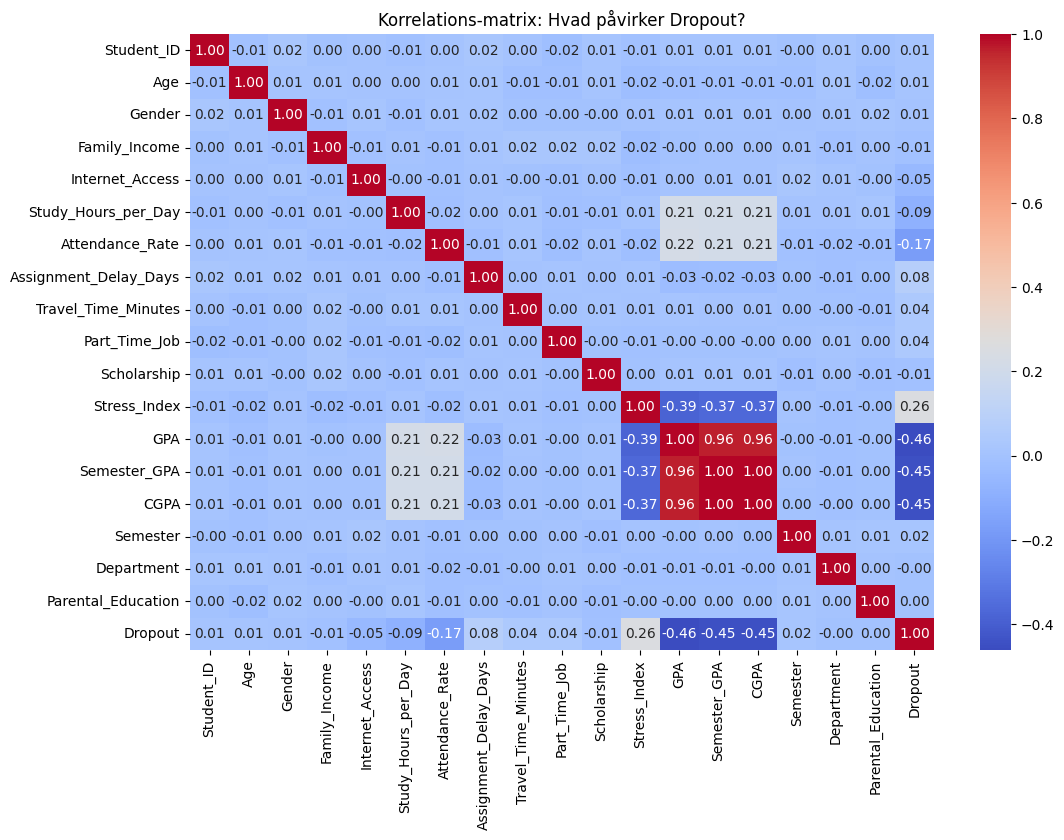


Top faktorer der korrelerer med Dropout:
Dropout                  1.000000
Stress_Index             0.256489
Assignment_Delay_Days    0.076948
Part_Time_Job            0.039171
Travel_Time_Minutes      0.036298
Semester                 0.015249
Age                      0.010582
Student_ID               0.009369
Gender                   0.006000
Parental_Education       0.000189
Department              -0.002924
Scholarship             -0.009890
Family_Income           -0.010070
Internet_Access         -0.046669
Study_Hours_per_Day     -0.087918
Attendance_Rate         -0.172975
CGPA                    -0.447683
Semester_GPA            -0.448178
GPA                     -0.461352
Name: Dropout, dtype: float64


In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# Beregn korrelationer
correlations = df_clean.corr()

# Lavheatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlations, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Korrelations-matrix: Hvad påvirker Dropout?")
plt.show()

# Print listen for Dropout
print("\nTop faktorer der korrelerer med Dropout:")
print(correlations['Dropout'].sort_values(ascending=False))

Det ses her at stress_index er den stærkest predictor for dropout. Hvad påvirker stress_index mest?

In [8]:
stress_corr = df_clean.corr()['Stress_Index'].sort_values(ascending=False)

print("Faktorer der påvirker stress mest (positivt og negativt):")
print(stress_corr)

Faktorer der påvirker stress mest (positivt og negativt):
Stress_Index             1.000000
Dropout                  0.256489
Study_Hours_per_Day      0.009945
Assignment_Delay_Days    0.006785
Travel_Time_Minutes      0.006411
Gender                   0.005113
Semester                 0.003862
Scholarship              0.000915
Parental_Education      -0.000449
Department              -0.007264
Part_Time_Job           -0.008513
Student_ID              -0.008864
Internet_Access         -0.012117
Attendance_Rate         -0.018644
Family_Income           -0.022015
Age                     -0.023803
CGPA                    -0.368278
Semester_GPA            -0.368395
GPA                     -0.385960
Name: Stress_Index, dtype: float64


For at lave supervised learning bruger vi random forest algoritmen, og lader modellen træne på 80% af data så det er muligt at teste modellens "læring" Som output af træning får vi en akurathedsscore.

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Definer Features (X) og Target (y)
# fjerner 'Dropout' fra X og akademiske resultater
X = df_clean.drop(columns=['Dropout', 'GPA', 'Semester_GPA', 'CGPA', 'Student_ID'])
y = df_clean['Dropout']

# 2. Split 80% træning, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialiser Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 4. Lav forudsigelser på test-sættet
y_pred = rf_model.predict(X_test)

# 5. Evaluering
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy Score: 0.7655210643015521

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.97      0.86      1369
           1       0.57      0.12      0.20       435

    accuracy                           0.77      1804
   macro avg       0.67      0.55      0.53      1804
weighted avg       0.73      0.77      0.70      1804



Akkuratetheds score tæt på 80% er fornuftigt, men da der ikke er mange der dropper ud, kan modellen stadig teste godt på trods af at den kun fanger 12 ud af 100 dropouts. Vi har på basis af korrelationsanalysen en formodning om at test_index er den vigtigste predictor og vi har med Random Forest mulighed for at se hvad der bliver vægte højest

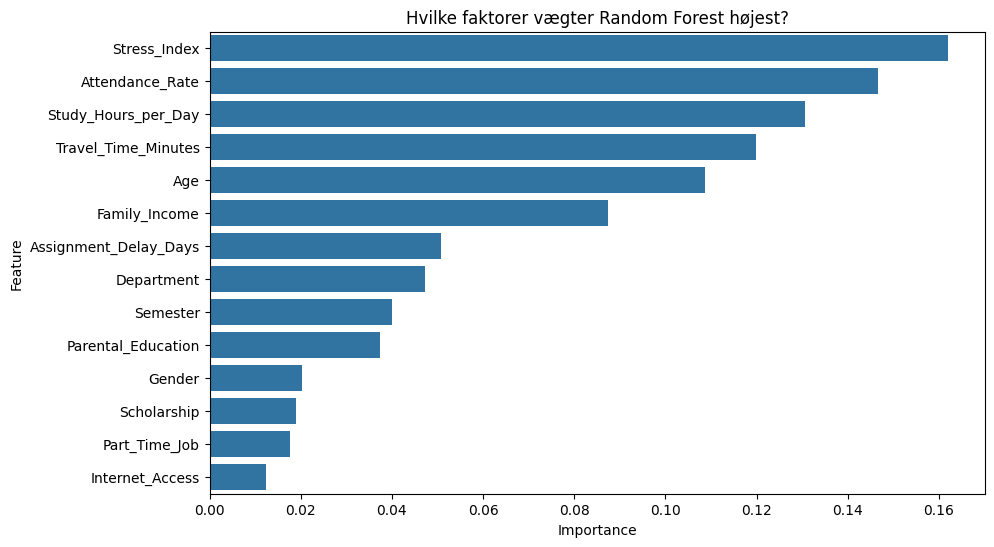

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Hent feature importances
importances = rf_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

# Visualisering
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Hvilke faktorer vægter Random Forest højest?')
plt.show()

Kan vi optimere modellen ved at vægte at modellem "gætter" rigtigt på dropouts

In [13]:
# Vi tilføjer 'balanced' for at straffe modellen hårdere, når den misser en dropout
custom_weights = {0: 1, 1: 20}

rf_model_balanced = RandomForestClassifier(n_estimators=100,
                                               class_weight=custom_weights,
                                               random_state=42)

rf_model_balanced.fit(X_train, y_train)
y_pred_balanced = rf_model_balanced.predict(X_test)

print("NY Accuracy Score:", accuracy_score(y_test, y_pred_balanced))
print("\nNY Classification Report:\n", classification_report(y_test, y_pred_balanced))

NY Accuracy Score: 0.7599778270509978

NY Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.98      0.86      1369
           1       0.52      0.06      0.11       435

    accuracy                           0.76      1804
   macro avg       0.64      0.52      0.49      1804
weighted avg       0.71      0.76      0.68      1804



Ved at "straffe" når den ikke finder dropout, opnås ikke noget ved disse parametere: custom_weights ={0: 1, 1: 20} vi øger betydningen af de rigtige gæt på dropouts

Da data er "ubalanceret" (mange der gennemføre) kan man imødegå modellens tendens til at gætte på elever der gennemføre ved at skabe kunstige dropouts. Vi bruger SMOTE til at skabe syntetiske data.

In [14]:
# Installér biblioteket hvis nødvendigt
# !pip install imbalanced-learn

from imblearn.over_sampling import SMOTE

# Lav kunstige data for at balancere sættet
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train, y_train)

# Træn modellen igen på det BALANCEREDE data
rf_model_smote = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model_smote.fit(X_res, y_res)

# Test på det RIGTIGE test-sæt
y_pred_smote = rf_model_smote.predict(X_test)

print("SMOTE Accuracy Score:", accuracy_score(y_test, y_pred_smote))
print("\nSMOTE Classification Report:\n", classification_report(y_test, y_pred_smote))

SMOTE Accuracy Score: 0.7638580931263859

SMOTE Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.95      0.86      1369
           1       0.53      0.18      0.27       435

    accuracy                           0.76      1804
   macro avg       0.66      0.56      0.56      1804
weighted avg       0.72      0.76      0.72      1804



Herved ses en forbedring fra 0,12 recal til 0,18.

In [15]:

y_probs = rf_model.predict_proba(X_test)[:, 1]

# grænse (f.eks. 0.3 i stedet for 0.5)
y_pred_adjusted = (y_probs >= 0.3).astype(int)

print("Justeret Classification Report (Threshold 0.3):")
print(classification_report(y_test, y_pred_adjusted))

Justeret Classification Report (Threshold 0.3):
              precision    recall  f1-score   support

           0       0.83      0.76      0.79      1369
           1       0.40      0.52      0.45       435

    accuracy                           0.70      1804
   macro avg       0.62      0.64      0.62      1804
weighted avg       0.73      0.70      0.71      1804



Ved at ændre grænserne for hvilken sansynlighed modellen accepter for at eleverne dropper ud.

Som en sidste test, prøver vi at visualisere hvilken feature modellen vægter højest

/tmp/ipykernel_12482/371212781.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Vigtighed', y='Faktor', data=feature_importance_df, palette='magma')


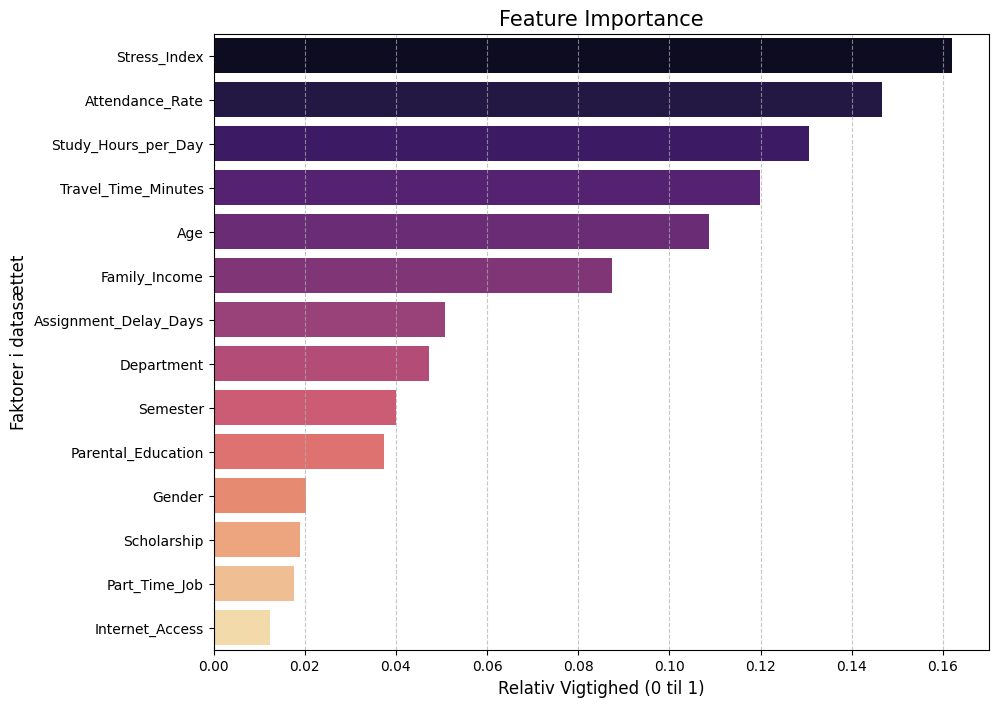

De 5 vigtigste faktorer ifølge modellen:
                 Faktor  Vigtighed
10         Stress_Index   0.161901
5       Attendance_Rate   0.146688
4   Study_Hours_per_Day   0.130599
7   Travel_Time_Minutes   0.119925
0                   Age   0.108604


In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Hent vigtigheden af hver feature
importances = rf_model.feature_importances_
feature_names = X.columns

# 2. Saml i tabel
feature_importance_df = pd.DataFrame({
    'Faktor': feature_names,
    'Vigtighed': importances
}).sort_values(by='Vigtighed', ascending=False)

# 3. Lav søjlediagram
plt.figure(figsize=(10, 8))
sns.barplot(x='Vigtighed', y='Faktor', data=feature_importance_df, palette='magma')

plt.title('Feature Importance', fontsize=15)
plt.xlabel('Relativ Vigtighed (0 til 1)', fontsize=12)
plt.ylabel('Faktorer i datasættet', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# 4. Print top 5 direkte i tekst
print("De 5 vigtigste faktorer ifølge modellen:")
print(feature_importance_df.head(5))

Nu vil vi prøve at lade modellen udvikle sig unsupervised for at se om der er features der har større betydning end umiddelbart antaget.

Vi prøver med k-means, som opdeler eleverne i k-grupper baseret på hvor tæt de ligger på hinanden. Denne metode kræver at vi skalere data.

Vi starter med at skalere data

In [19]:
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X) # X er de features, du brugte til Random Forest

print(X_scaled) #Tjek af data

[[ 0.5015885  -0.99955664 -0.65204068 ... -1.35779748 -1.40047174
   0.11792452]
 [-0.15210146 -0.99955664 -0.65204068 ...  0.43786754  0.70724602
  -0.98892161]
 [ 0.64166492 -0.99955664  0.08437191 ... -1.35779748 -1.40047174
   1.22477064]
 ...
 [-0.75909928 -0.99955664 -0.65204068 ...  1.33570005 -0.69789916
  -0.98892161]
 [ 0.5015885   1.00044356  0.09014371 ... -1.35779748  0.00467343
   0.11792452]
 [ 0.64166492  1.00044356  1.86019187 ... -1.35779748 -1.40047174
   1.22477064]]


Nu er data skaleret og vi kan nu lave cluster og se om dropout optræder hyppigere i nogle clustre

In [22]:
from sklearn.cluster import KMeans

# 1. Definer modellen. Vi bruger n_init=10 for at sikre stabilitet.
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

# 2. Fit modellen på dine SKALEREDE features (X_scaled_df)
clusters = kmeans.fit_predict(X_scaled)

# 3. Tilføj cluster-ID til dit oprindelige (rensede) dataframe, så vi kan læse resultaterne

df_clean.loc[:, 'Cluster'] = clusters
# 4. Beregn frafaldsraten og antallet af studerende i hver klynge
cluster_summary = df_clean.groupby('Cluster').agg({
    'Dropout': ['mean', 'count']
}).reset_index()

cluster_summary.columns = ['Cluster', 'Frafaldsrate', 'Antal_Studerende']
print(cluster_summary.sort_values(by='Frafaldsrate', ascending=False))

   Cluster  Frafaldsrate  Antal_Studerende
2        2      0.287647              1109
3        3      0.245775              2071
0        0      0.221894              3051
1        1      0.219792              2789


Vi kan se at den højeste frafaldsrate finde i cluster 2. # Vi kigger på gennemsnittet for hver klynge for at se forskellene.


In [30]:
profile = df_clean.groupby('Cluster')[['Stress_Index', 'Attendance_Rate', 'Family_Income', 'Dropout']].mean()

# Gør det nemt at læse ved at sortere efter frafaldsrate
print("Gennemsnitsværdier:")
print(profile.sort_values(by='Dropout', ascending=False))

Gennemsnitsværdier:
         Stress_Index  Attendance_Rate  Family_Income   Dropout
Cluster                                                        
2            5.561407        82.093688   38890.566276  0.287647
3            5.447320        81.635876   38470.232255  0.245775
0            5.526221        82.068404   37765.527696  0.221894
1            5.499606        82.066332   38987.414844  0.219792


Ved at vurder tal se at cluster 2 har den højeste gennemsnitslige stress_Index og den højeste frafaldsrate, hvilket er i overensstemmelse med de resultater vi observerede under supervised learning. Vi prøver her

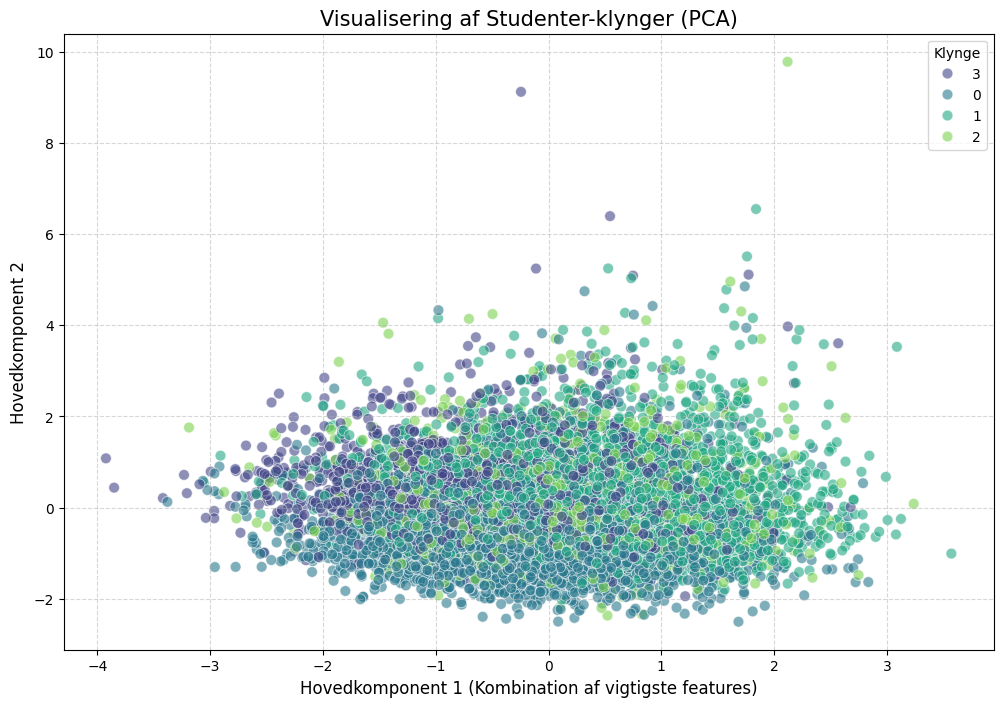

In [32]:
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Brug PCA til at reducere skalerede data til 2 dimensioner
pca = PCA(n_components=2)
pca_data = pca.fit_transform(X_scaled)

# 2. Lav en ny DataFrame til plottet
df_pca = pd.DataFrame(data=pca_data, columns=['PC1', 'PC2'])
df_pca['Cluster'] = clusters.astype(str) # Vi gør Cluster til tekst for bedre farver
df_pca['Dropout'] = df_clean['Dropout'].values

# 3. Tegn diagrammet
plt.figure(figsize=(12, 8))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=df_pca, palette='viridis', alpha=0.6, s=60)

plt.title('Visualisering af Studenter-klynger (PCA)', fontsize=15)
plt.xlabel('Hovedkomponent 1 (Kombination af vigtigste features)', fontsize=12)
plt.ylabel('Hovedkomponent 2', fontsize=12)
plt.legend(title='Klynge')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Hovedekonponent 1 er PC1 som vi viser hvordan er fremkommet ved nedstående metode. Hovedekomponent 2 (PC2) er de næstmest betydende komponeter. PC1 fanger eksempelvis "Generel Mistrivsel" (Stress + Fravær), så fanger PC2 måske "Socioøkonomisk baggrund" (Indkomst + Forældreuddannelse).

Vigtigste faktorer i PC1 (Opskriften på X-aksen):
Attendance_Rate          0.455868
Age                      0.423810
Scholarship              0.323352
Family_Income            0.144623
Travel_Time_Minutes      0.074560
Assignment_Delay_Days    0.003661
Gender                  -0.016869
Internet_Access         -0.037022
Department              -0.097230
Part_Time_Job           -0.138287
Study_Hours_per_Day     -0.238903
Semester                -0.325543
Stress_Index            -0.330619
Parental_Education      -0.423002
Name: PC1, dtype: float64


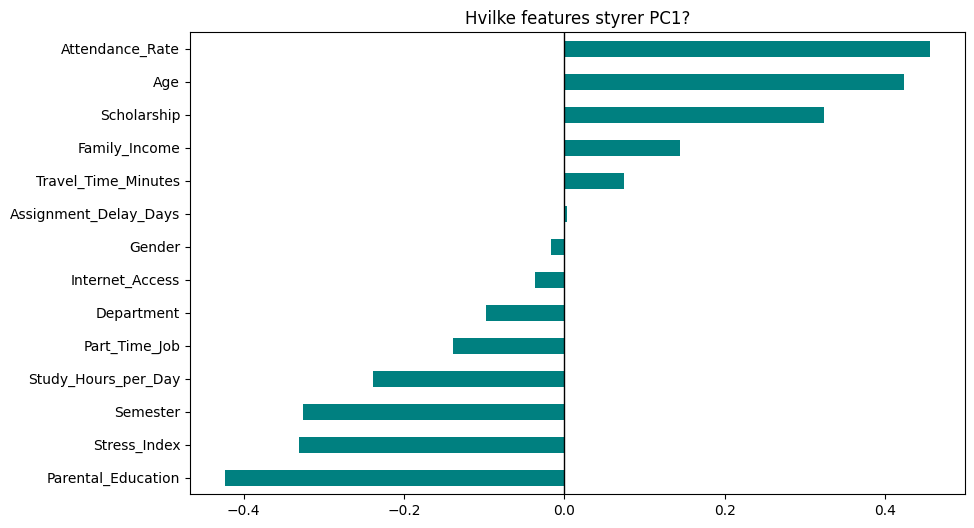

In [33]:
# 1. Træk vægtene (loadings) fra PCA-model
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=X.columns
)

# 2. Vis de vigtigste bidragsydere til PC1
print("Vigtigste faktorer i PC1 (Opskriften på X-aksen):")
print(loadings['PC1'].sort_values(ascending=False))

# 3. Visualisér det med et barplot
plt.figure(figsize=(10, 6))
loadings['PC1'].sort_values().plot(kind='barh', color='teal')
plt.title('Hvilke features styrer PC1?')
plt.axvline(0, color='black', lw=1)
plt.show()

In [ ]:
vi kan visualiser hvorledes dropouts fordeler sig i de to clusteres.

Hvad trækker i PC1 (X-aksen):
Attendance_Rate    0.455868
Age                0.423810
Scholarship        0.323352
Name: PC1, dtype: float64
Parental_Education   -0.423002
Stress_Index         -0.330619
Semester             -0.325543
Name: PC1, dtype: float64

Hvad trækker i PC2 (Y-aksen):
Family_Income    0.658758
Part_Time_Job    0.456273
Scholarship      0.249664
Name: PC2, dtype: float64
Attendance_Rate   -0.271976
Gender            -0.227125
Stress_Index      -0.206007
Name: PC2, dtype: float64


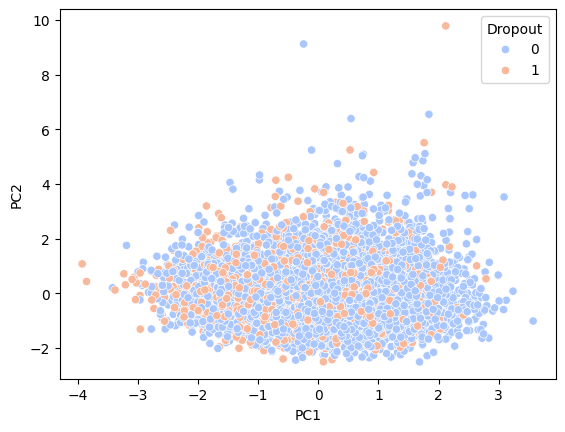

In [44]:

sns.scatterplot(x='PC1', y='PC2', hue='Dropout', data=df_pca, palette='coolwarm', alpha=1.0)
# Træk loadings ud
loadings = pd.DataFrame(pca.components_.T, columns=['PC1', 'PC2'], index=X.columns)

# Se de top 3 features for hver akse
print("Hvad trækker i PC1 (X-aksen):")
print(loadings['PC1'].sort_values(ascending=False).head(3))
print(loadings['PC1'].sort_values(ascending=True).head(3))

print("\nHvad trækker i PC2 (Y-aksen):")
print(loadings['PC2'].sort_values(ascending=False).head(3))
print(loadings['PC2'].sort_values(ascending=True).head(3))

Vi kan se at dropouts (de røde) ligger spredt sammen med dem der gennemfører. dog er der en lille tedens til at dropouts er placeret lidt til venstre på PC1 aksen. Vi kan prøve at se om tabel over features vil give ekstra indsigt.

In [46]:
# 1.Alle numeriske kolonner med (minus ikke-relevante ID'er)
# Grupperer på Cluster og beregner gennemsnittet for ALT
full_profile = df_clean.groupby('Cluster').mean()

# 2. Vi sorterer efter Dropout-rate, så Cluster 2 ligger øverst
full_profile_sorted = full_profile.sort_values(by='Dropout', ascending=False)

# 3. Vis hele tabellen (transponeret med .T
print("Gennemsnitsværdier for alle faktorer:")
display(full_profile_sorted.T)

Gennemsnitsværdier for alle faktorer:


Cluster,2,3,0,1
Student_ID,4965.591524,4891.742636,5047.105539,5003.448548
Age,21.001713,21.033221,20.999049,21.058982
Gender,0.480613,0.507484,0.499836,0.501613
Family_Income,38890.566276,38470.232255,37765.527696,38987.414844
Internet_Access,0.0,1.0,1.0,1.0
Study_Hours_per_Day,4.026483,4.001931,4.034821,4.00228
Attendance_Rate,82.093688,81.635876,82.068404,82.066332
Assignment_Delay_Days,1.782687,1.810719,1.789905,1.812478
Travel_Time_Minutes,30.1789,30.272042,29.938709,30.291466
Part_Time_Job,0.41028,1.0,0.0,0.397634


Ud fra tabellen af en væsentlig faktor for om eleverne dropper ud er adgang til internet. I følge tabel så har ingen af dropouts internet og kombineret med stress_index så har vi en stærk indikator